# From probability map to coordinated drone routes

## A practical solution to the optimal-search-path problem

Andrew Wheeler's [2020 post](https://andrewpwheeler.com/2020/12/20/a-failed-attempt-at-optimal-search-paths/) asks a deceptively hard question: given a multimodal probability surface, how should a limited number of searchers traverse it without disconnected “hop-scotching”? This notebook turns that question into a precise optimization problem, validates the model against exact solutions, and solves Wheeler's original 100 × 100 simulated surface at operational scale.

**Bottom line.** This is a grid **team-orienteering** problem. A full integer program can certify small cases but is too large for long routes on 10,000 cells. The useful solution is a decomposition: generate a diverse library of legal flight paths, then let CP-SAT select the best nonoverlapping team. Every plotted line below is an ordered, contiguous route—not merely a connected set of cells.

The motivation is wilderness search and rescue, but the same machinery applies to disaster assessment, wildlife surveys, maritime search, infrastructure inspection, environmental sensing, and other spatial searches with a probabilistic reward map.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from search_planner import (
    generate_candidates,
    greedy_endpoint_plan,
    make_probability_surface,
    path_score,
    plan_from_candidates,
    plot_paths,
    plot_surface,
    solve_exact_small,
    validate_paths,
)

OUTPUT = Path("artifacts")
OUTPUT.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 125, "savefig.dpi": 180, "font.size": 10})
pd.set_option("display.precision", 4)

## 1. The probability surface

Rossmo, Velarde, and Mahood motivate prioritizing search areas with probability maps that combine incomplete evidence through Bayesian updating. Their Joshua Tree case integrates earlier search tracks and a cell-phone-tower ping into a GIS probability surface. That work answers **where is the subject likely to be?**; the present problem answers **how should limited search assets move across that surface?**

Below I reproduce Wheeler's synthetic data exactly in substance: the same repeated point locations, Gaussian kernel bandwidth 2, extent 0–10, and normalization. The western mode is tall and concentrated; the northeastern mode is broader and carries substantial mass; a third mode sits in the southeast.

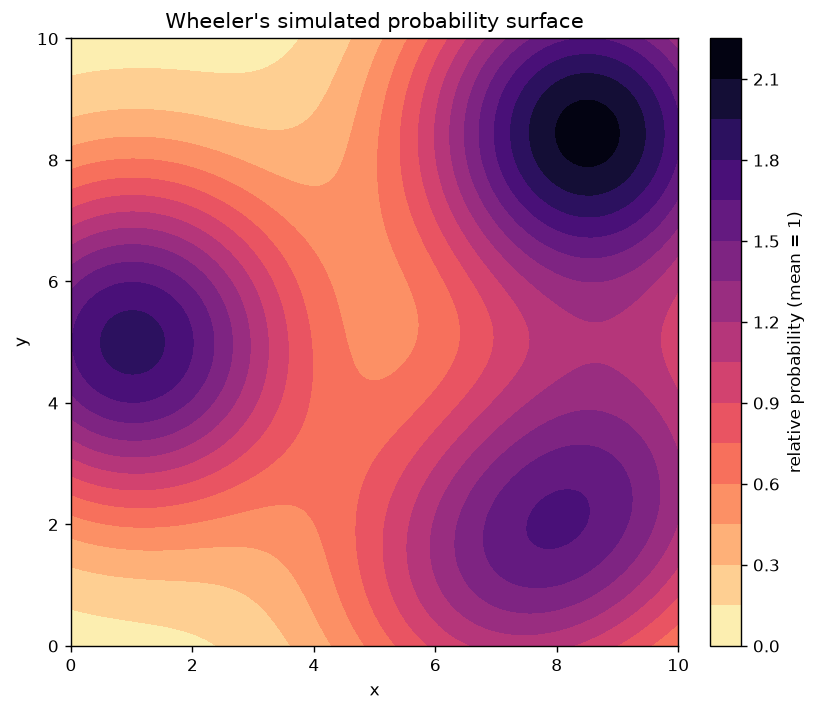

Grid: 100 × 100 = 10,000 cells
Probability sums to 1.000000000000


In [2]:
x, y, probability = make_probability_surface(grid_size=100)
assert np.isclose(probability.sum(), 1.0)

fig, ax = plt.subplots(figsize=(7.2, 5.8))
plot_surface(probability, ax=ax, title="Wheeler's simulated probability surface")
fig.tight_layout()
fig.savefig(OUTPUT / "probability_surface.png", bbox_inches="tight")
plt.show()

print(f"Grid: {probability.shape[0]} × {probability.shape[1]} = {probability.size:,} cells")
print(f"Probability sums to {probability.sum():.12f}")

## 2. What is being optimized?

Let $p_i$ be the posterior probability that the target is in cell $i$. Drone $d$ follows an ordered route $R_d=(v_{d,1},\ldots,v_{d,L})$. Under perfect detection in a scanned cell, a stationary target, and no credit for repeat coverage, the objective is

$$\max \sum_{d=1}^{k}\sum_{i\in R_d}p_i.$$

The constraints are:

1. consecutive route cells share an edge or corner (8-neighbor/queen adjacency);
2. each route contains exactly $L$ distinct cells;
3. routes are mutually disjoint, so probability is not counted twice;
4. starts and ends are free; and
5. turns cost nothing, as requested.

Here $L$ counts scanned cells, so a route has $L-1$ between-cell moves. If “budget” instead means distance, use $L=B+1$. Free starts model drones deployed near their assigned search area. A common base, obstacles, terrain-dependent travel times, mandatory returns, heterogeneous sensor widths, or non-unit probability of detection would change the model and should be represented explicitly.

The sum of covered probabilities is also the probability of finding the target under these assumptions. With cell-specific probability of detection $q_i$, replace $p_i$ by $p_iq_i$. Repeated imperfect searches require the nonlinear cumulative reward $p_i[1-(1-q_i)^{n_i}]$.

## 3. Why the earlier formulations struggle

This is the **team orienteering problem** (TOP): multiple length-limited paths collect vertex prizes. TOP is NP-hard. A model that merely selects neighboring cells does not define an order and may contain disconnected components or subtours. A correct time-indexed model uses a binary variable $x_{dti}$ for drone $d$, step $t$, and cell $i$, with

$$\sum_i x_{dti}=1, \qquad
x_{dti}\leq\sum_{j\in N(i)}x_{d,t-1,j}, \qquad
\sum_{d,t}x_{dti}\leq1.$$

Those constraints enforce an actual ordered simple path, but the 100 × 100, 8-drone, 300-cell case would require 24 million binary visit variables before presolve. That is why a correct direct model is useful as an auditor on small grids, not as the primary full-scale planner.

The scalable solver uses two levels:

- **Route generation:** translated and rotated serpentine sweeps cover compact high-mass regions; bidirectional beam search contributes irregular probability-following routes and geographic diversity. After each master solve, nearby translations of the incumbent routes are added and the master is re-solved so a useful route is not discarded merely because it scores slightly worse in isolation.
- **Team selection:** one Boolean variable per complete route; CP-SAT chooses exactly $k$ routes, with one set-packing constraint per cell to prevent overlap.

This master problem is solved exactly over the generated route library. It is not a proof of global optimality because ungenerated routes remain possible. To report quality honestly, we use three distinct checks: an exact small-case optimum, the CP-SAT bound within the candidate library, and a global relaxation equal to the sum of the largest $kL$ cell probabilities (which ignores contiguity and is therefore optimistic).

## 4. Exact validation on a small instance

The next experiment solves a 6 × 6, two-drone, five-cell instance twice: once with the full time-indexed model and once with the scalable method. It also includes a sequential endpoint-greedy baseline in the spirit of the original post. The exact solver's status and bound provide a genuine certificate.

In [3]:
_, _, small_probability = make_probability_surface(grid_size=6)
small_k, small_length = 2, 5

exact = solve_exact_small(small_probability, small_k, small_length, time_limit=60)
small_candidates = generate_candidates(small_probability, small_length)
hybrid = plan_from_candidates(
    small_probability, small_candidates, small_k, small_length, time_limit=15
)
greedy_paths = greedy_endpoint_plan(small_probability, small_k, small_length)
greedy_score = path_score(small_probability, greedy_paths)

for name, paths in [("exact", exact.paths), ("hybrid", hybrid.paths), ("greedy", greedy_paths)]:
    validate_paths(paths, small_probability.shape, small_length)

validation = pd.DataFrame(
    [
        {"method": "Exact time-indexed CP-SAT", "covered_probability": exact.score,
         "percent_of_exact": 100.0, "status": exact.status},
        {"method": "Hybrid route library + CP-SAT", "covered_probability": hybrid.score,
         "percent_of_exact": 100 * hybrid.score / exact.score, "status": hybrid.status},
        {"method": "Sequential endpoint greedy", "covered_probability": greedy_score,
         "percent_of_exact": 100 * greedy_score / exact.score, "status": "feasible"},
    ]
)
display(validation.style.format({"covered_probability": "{:.4%}", "percent_of_exact": "{:.2f}%"}))
assert exact.status == "OPTIMAL"
assert exact.candidate_gap < 1e-8
print(f"Exact certificate: objective = bound = {exact.score:.8f}")

,method,covered_probability,percent_of_exact,status
0,Exact time-indexed CP-SAT,44.3914%,100.00%,OPTIMAL
1,Hybrid route library + CP-SAT,44.3914%,100.00%,OPTIMAL (enriched candidate library)
2,Sequential endpoint greedy,43.2220%,97.37%,feasible


Exact certificate: objective = bound = 0.44391379


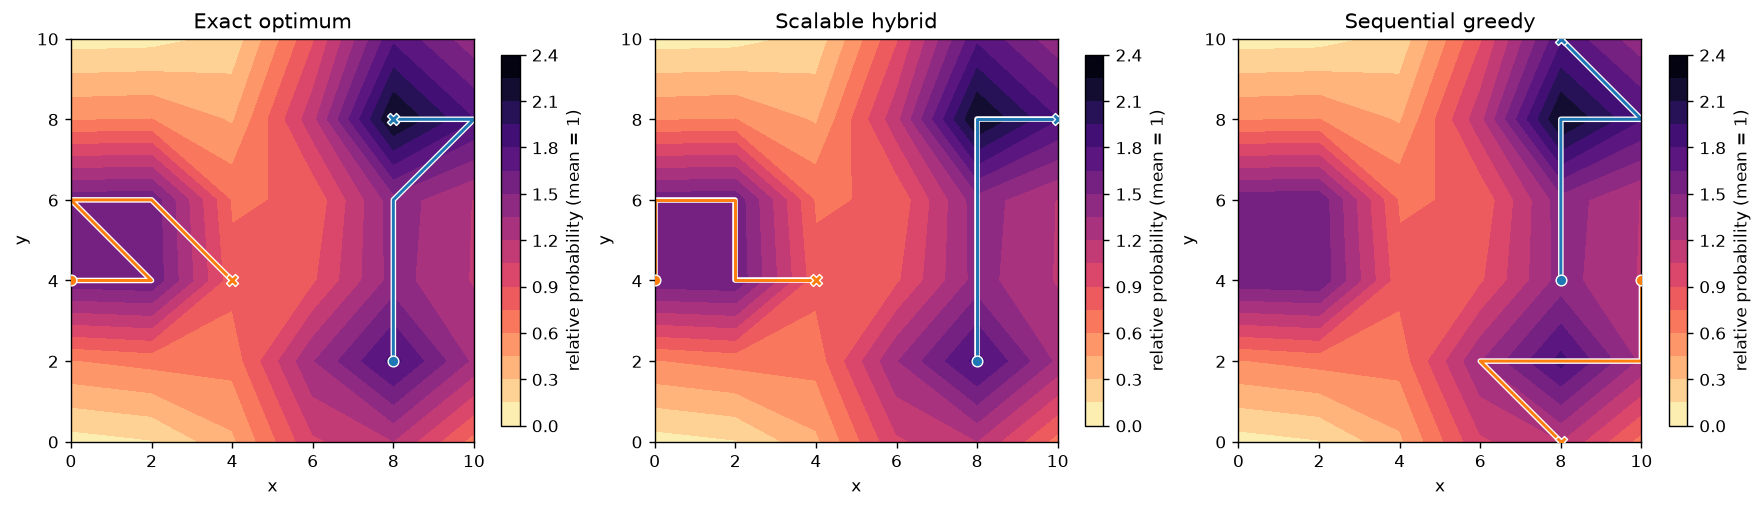

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
plot_paths(small_probability, exact.paths, axes[0], "Exact optimum")
plot_paths(small_probability, hybrid.paths, axes[1], "Scalable hybrid")
plot_paths(small_probability, greedy_paths, axes[2], "Sequential greedy")
for ax in axes:
    legend = ax.get_legend()
    if legend:
        legend.remove()
fig.savefig(OUTPUT / "small_exact_validation.png", bbox_inches="tight")
plt.show()

The visual audit matters: each route is shown in traversal order, with a circle at its start and an X at its end. Lines may touch or cross geometrically at diagonal moves, but the validation function confirms that no cell is repeated within or across drones.

## 5. Full-scale plans for different fleet sizes and budgets

We now return to all 10,000 cells. Candidate routes only depend on path length, so the same library can be reused across fleet sizes. This is operationally convenient: once routes are generated, incident command can rapidly evaluate how the allocation changes as drones become available.

In [5]:
lengths = [100, 300]
fleet_sizes = [1, 2, 4, 8]

candidate_libraries = {}
for length in lengths:
    candidate_libraries[length] = generate_candidates(probability, length)
    print(f"length {length}: {len(candidate_libraries[length]):,} valid candidate routes")

plans = {}
rows = []
for length in lengths:
    for drones in fleet_sizes:
        result = plan_from_candidates(
            probability,
            candidate_libraries[length],
            drones=drones,
            length=length,
            time_limit=12,
            random_seed=2026 + drones + length,
        )
        validate_paths(result.paths, probability.shape, length)
        plans[(drones, length)] = result
        rows.append(
            {
                "drones": drones,
                "cells_per_drone": length,
                "total_unique_cells": drones * length,
                "covered_probability": result.score,
                "global_relaxation_bound": result.global_relaxation_bound,
                "fraction_of_global_bound": result.score / result.global_relaxation_bound,
                "candidate_gap": result.candidate_gap,
                "runtime_seconds": result.runtime_seconds,
                "status": result.status,
            }
        )

results = pd.DataFrame(rows)
display(
    results.style.format(
        {
            "covered_probability": "{:.2%}",
            "global_relaxation_bound": "{:.2%}",
            "fraction_of_global_bound": "{:.2%}",
            "candidate_gap": "{:.3%}",
            "runtime_seconds": "{:.2f}",
        }
    )
)
results.to_csv(OUTPUT / "scenario_results.csv", index=False)

length 100: 4,771 valid candidate routes


length 300: 4,114 valid candidate routes


,drones,cells_per_drone,total_unique_cells,covered_probability,global_relaxation_bound,fraction_of_global_bound,candidate_gap,runtime_seconds,status
0,1,100,100,2.13%,2.13%,99.92%,0.000%,0.05,OPTIMAL (enriched candidate library)
1,2,100,200,4.18%,4.18%,99.86%,0.000%,26.32,OPTIMAL (enriched candidate library)
2,4,100,400,8.04%,8.08%,99.48%,0.000%,25.33,OPTIMAL (enriched candidate library)
3,8,100,800,15.10%,15.29%,98.77%,0.000%,25.24,OPTIMAL (enriched candidate library)
4,1,300,300,6.15%,6.17%,99.78%,0.000%,0.12,OPTIMAL (enriched candidate library)
5,2,300,600,11.41%,11.75%,97.07%,0.000%,16.50,OPTIMAL (enriched candidate library)
6,4,300,1200,21.70%,22.01%,98.58%,0.000%,38.01,OPTIMAL (enriched candidate library)
7,8,300,2400,39.19%,40.32%,97.20%,0.000%,38.77,OPTIMAL (enriched candidate library)


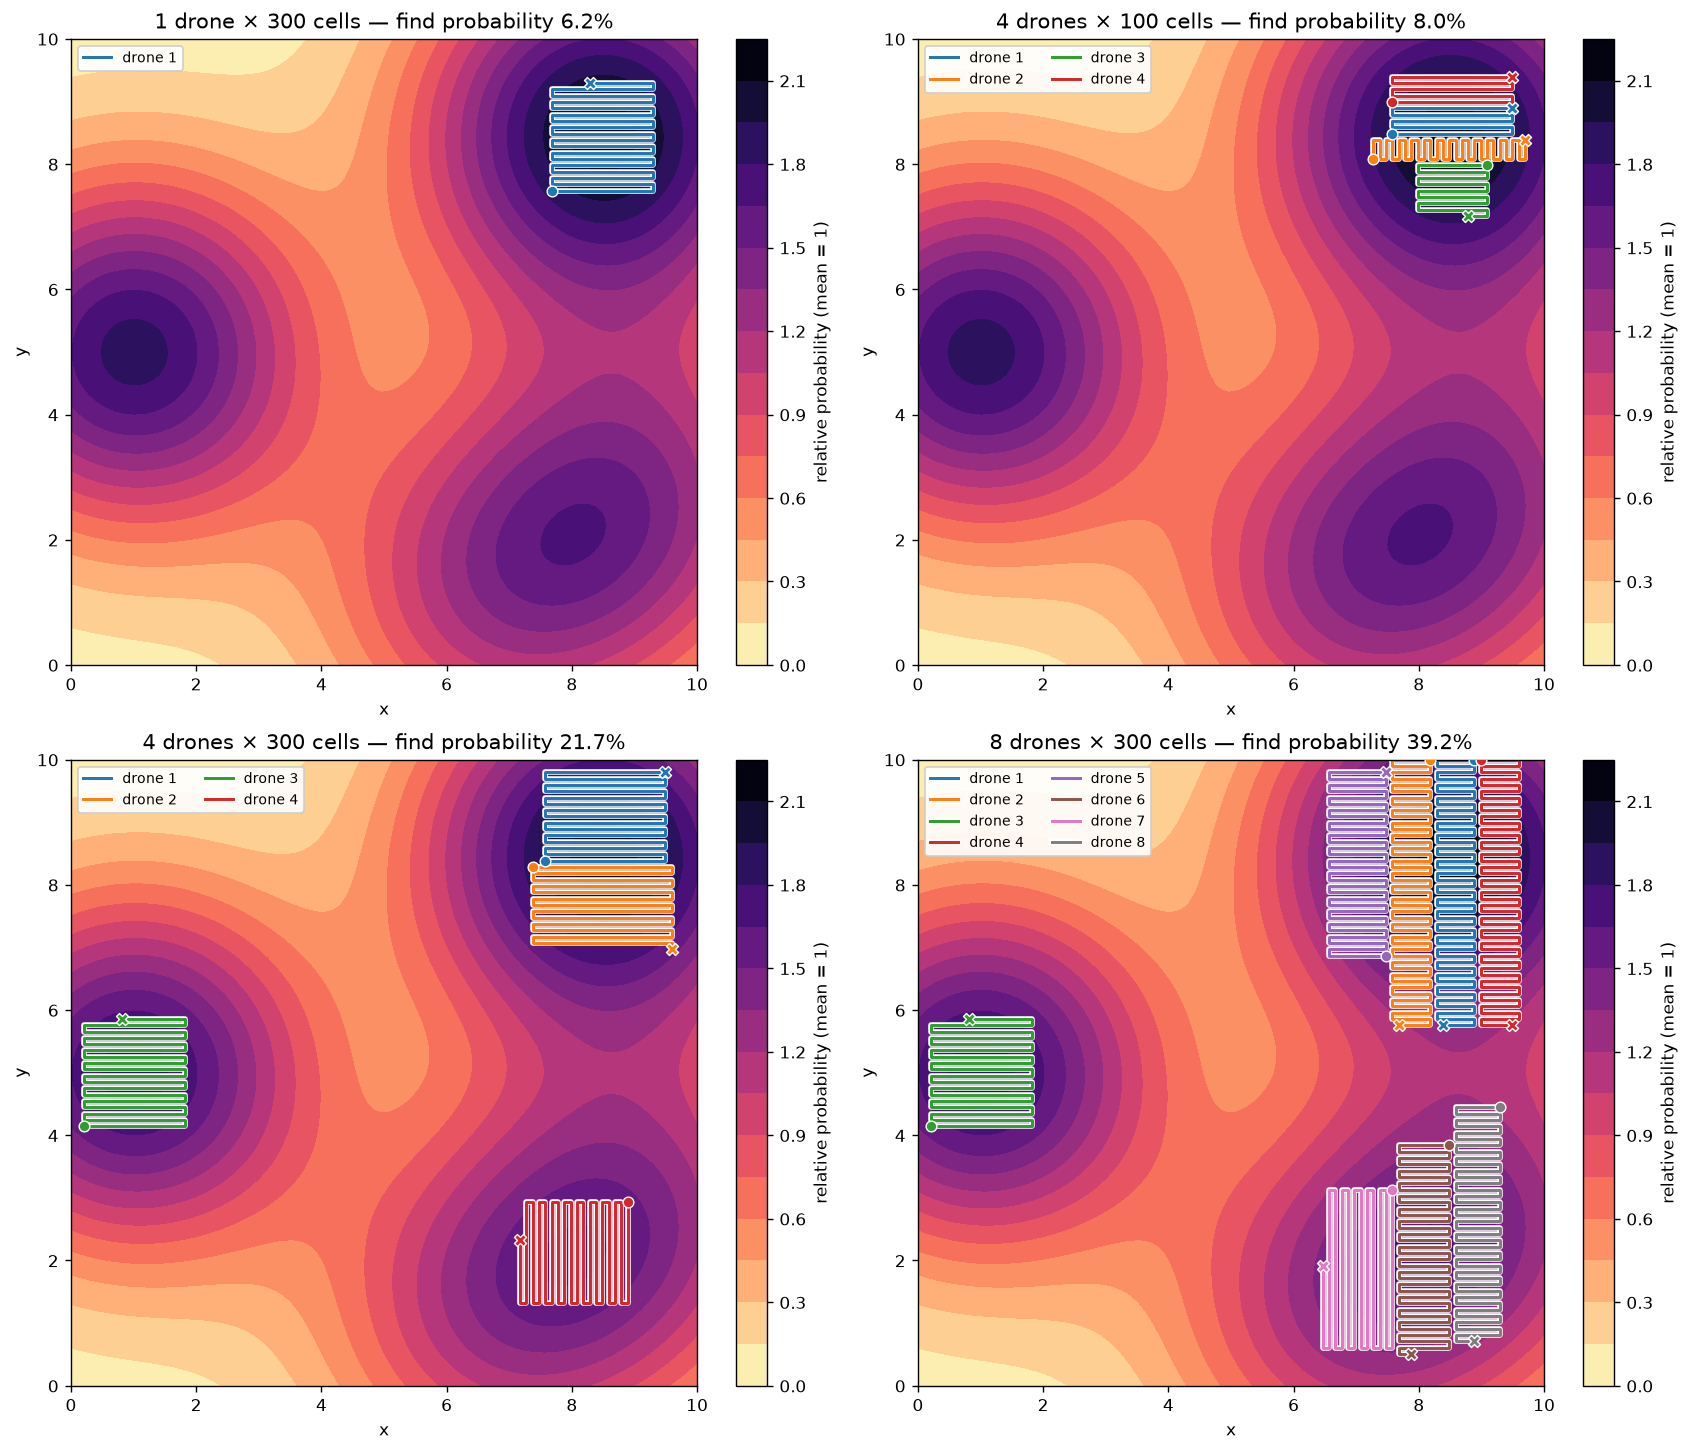

In [6]:
show_cases = [(1, 300), (4, 100), (4, 300), (8, 300)]
fig, axes = plt.subplots(2, 2, figsize=(13.5, 11.5), constrained_layout=True)
for ax, (drones, length) in zip(axes.ravel(), show_cases):
    result = plans[(drones, length)]
    plot_paths(
        probability,
        result.paths,
        ax=ax,
        title=(f"{drones} drone{'s' if drones > 1 else ''} × {length} cells "
               f"— find probability {result.score:.1%}"),
    )
fig.savefig(OUTPUT / "full_scale_flight_paths.png", bbox_inches="tight")
plt.show()

## 6. Interpretation

The routes make the allocation trade-off explicit. A single drone concentrates on one high-value connected region because reaching another mode would spend budget on lower-probability bridge cells. With more drones, free deployment allows separate modes to be searched without paying that bridge cost. Longer routes widen each local sweep and eventually make secondary modes worthwhile. This is the behavior the original greedy experiment was trying to elicit, but here all drones are coordinated in one master optimization.

The “global relaxation bound” is deliberately generous: it simply adds the $kL$ largest cell probabilities even if those cells cannot be arranged into $k$ paths. The reported fraction of that bound is therefore a conservative quality indicator, not an optimality gap. By contrast, a zero candidate gap means CP-SAT proved that no better combination exists **among the generated routes**.

There is no universal polynomial-time “best” solver for arbitrary maps because TOP is NP-hard. For this smooth, obstacle-free surface, compact sweeps are a strong route family and the exact small-instance comparison checks the implementation. For a mission-critical deployment I would additionally (a) use the true posterior raster and sensor footprint, (b) encode no-fly cells and launch/recovery locations, (c) use flight time rather than cell count, (d) run more route-generation rounds, and (e) replan as negative searches update the posterior.

## 7. Reuse and extensions

The functions in `search_planner.py` accept any nonnegative 2-D array after normalization. The clean extension points are:

- **Obstacles:** remove forbidden cells and their transitions; generate paths only on the remaining graph.
- **Common base / return:** prepend and append shortest base connections and charge them to a distance budget.
- **Terrain and wind:** replace unit moves with directed edge times; use a resource-constrained path generator.
- **Sensor footprint:** score the union of cells detected from each waypoint rather than the waypoint alone.
- **Imperfect detection:** maximize posterior probability of detection, then Bayesian-update after completed sweeps.
- **Robustness:** reserve slack or optimize expected coverage under drone-failure scenarios.

The set-packing architecture survives all of these changes: route generation enforces per-drone physics, while the master problem coordinates the fleet.

## References

- Rossmo, D. K., Velarde, L., & Mahood, T. (2019). [Optimizing Wilderness Search and Rescue: A Bayesian GIS Analysis](https://journalofsar.com/wp-content/uploads/2019/11/vol3iss2_complete.pdf#page=30). *Journal of Search & Rescue, 3*(2), 44–58.
- Vansteenwegen, P., Souffriau, W., & Van Oudheusden, D. (2011). [The orienteering problem: A survey](https://doi.org/10.1016/j.ejor.2010.03.045). *European Journal of Operational Research, 209*(1), 1–10.
- Wheeler, A. P. (2020). [A failed attempt at optimal search paths](https://andrewpwheeler.com/2020/12/20/a-failed-attempt-at-optimal-search-paths/).

*Reproducibility:* the notebook uses deterministic route generation and fixed CP-SAT seeds. `validate_paths` checks exact length, bounds, no revisits, no inter-drone overlaps, and every move's 8-neighbor adjacency before results are reported.